# Notebook 02: Baseline ML — Metadata-Only LightGBM
## Project 28 — Binary Skin Cancer Detection (ISIC 2024)

**Model:** LightGBM gradient boosted trees on metadata features only (no images).  
**Why LightGBM over XGBoost?** Faster on large datasets, native categorical support, handles class imbalance with `is_unbalance`.  
**Why tree model for baseline?** No feature scaling required, handles mixed types, built-in feature importance via SHAP.

---
**Design decisions from EDA:**
- GroupKFold by patient_id (no leakage)
- Primary metric = pAUC @ TPR≥0.80
- class_weight='balanced' to address ~3.5% positive rate
- Systematic hyperparameter search with Optuna

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from pathlib import Path
from sklearn.model_selection import GroupKFold

from src.data.preprocessing import (
    SkinCancerFeatureEngineer, MetadataPreprocessor,
    get_group_kfold_splits, load_dataset
)
from src.evaluation.metrics import pauc_score, compute_all_metrics, plot_evaluation_dashboard

# Seeds
SEED = 42
np.random.seed(SEED)

DATA_DIR = Path('../data/raw/isic-2024-challenge')
FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'target'
GROUP_COL = 'patient_id'
N_FOLDS = 5
MIN_TPR = 0.80

print('Setup complete.')

Setup complete.


## 1. Load & Engineer Features

In [2]:
df_raw = load_dataset(DATA_DIR)

# Feature engineering (domain-informed)
engineer = SkinCancerFeatureEngineer()
df = engineer.transform(df_raw)

print(f'Features after engineering: {df.shape[1]} (was {df_raw.shape[1]})')
new_features = [c for c in df.columns if c not in df_raw.columns]
print(f'New engineered features: {new_features}')

Loaded dataset: 401,059 rows × 55 columns
Positive rate: 0.10%


Features after engineering: 62 (was 55)
New engineered features: ['age_risk_group', 'age_risk_score', 'site_risk_tier', 'age_site_interaction', 'is_male', 'color_variability_index', 'circularity']


In [3]:
# Prepare X, y, groups
drop_cols = ['isic_id', 'patient_id', 'lesion_id', 'image_type', 'attribution',
             'copyright_license', 'tbp_tile_type']  # Non-informative ID/meta cols
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=[TARGET] + drop_cols)
y = df[TARGET].values
groups = df[GROUP_COL].values if GROUP_COL in df.columns else None

# Preprocess: impute + encode (no scaling — LightGBM doesn't need it)
preprocessor = MetadataPreprocessor(drop_cols=[])
X_processed = preprocessor.fit(X).transform(X, scale=False)

print(f'Final feature matrix: {X_processed.shape}')
print(f'Feature names: {X_processed.columns.tolist()[:10]} ...')

Final feature matrix: (401059, 55)
Feature names: ['age_approx', 'clin_size_long_diam_mm', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext'] ...


## 2. Cross-Validation — GroupKFold

In [4]:
splits = get_group_kfold_splits(df, n_splits=N_FOLDS, target_col=TARGET, group_col=GROUP_COL)

# Default LightGBM params
DEFAULT_PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 127,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'is_unbalance': True,       # Address class imbalance
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1,
}

print('Starting cross-validation...')
oof_probs = np.zeros(len(y))
fold_scores = []
models = []

for fold, (train_idx, val_idx) in enumerate(splits):
    X_train = X_processed.iloc[train_idx]
    y_train = y[train_idx]
    X_val = X_processed.iloc[val_idx]
    y_val = y[val_idx]

    model = lgb.LGBMClassifier(**DEFAULT_PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(-1)]
    )

    val_probs = model.predict_proba(X_val)[:, 1]
    oof_probs[val_idx] = val_probs

    fold_pauc = pauc_score(y_val, val_probs, min_tpr=MIN_TPR)
    fold_scores.append(fold_pauc)
    models.append(model)

    print(f'Fold {fold+1}: pAUC={fold_pauc:.4f} | best_iter={model.best_iteration_}')

oof_pauc = pauc_score(y, oof_probs, min_tpr=MIN_TPR)
print(f'\nOOF pAUC: {oof_pauc:.4f} ± {np.std(fold_scores):.4f}')
print(f'Per-fold: {[round(s,4) for s in fold_scores]}')

GroupKFold (5 folds) by patient_id
  Fold 1: train=320,845 (316 positives), val=80,214 (77 positives)


  Fold 2: train=320,847 (315 positives), val=80,212 (78 positives)
  Fold 3: train=320,848 (313 positives), val=80,211 (80 positives)
  Fold 4: train=320,848 (313 positives), val=80,211 (80 positives)
  Fold 5: train=320,848 (315 positives), val=80,211 (78 positives)
Starting cross-validation...


Fold 1: pAUC=5.0000 | best_iter=1


Fold 2: pAUC=5.0000 | best_iter=1


Fold 3: pAUC=5.0000 | best_iter=1


Fold 4: pAUC=5.0000 | best_iter=1


Fold 5: pAUC=5.0000 | best_iter=1

OOF pAUC: 5.0000 ± 0.0000
Per-fold: [5.0, 5.0, 5.0, 5.0, 5.0]


## 3. Hyperparameter Tuning with Optuna

In [5]:
def objective(trial):
    """Optuna objective: maximize OOF pAUC via 3-fold CV."""
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'n_estimators': 500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 511),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'is_unbalance': True,
        'random_state': SEED,
        'n_jobs': -1,
        'verbose': -1,
    }

    # Use 3-fold for speed during tuning
    quick_splits = list(GroupKFold(n_splits=3).split(X_processed, y, groups=groups))
    scores = []

    for train_idx, val_idx in quick_splits:
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_processed.iloc[train_idx], y[train_idx],
            eval_set=[(X_processed.iloc[val_idx], y[val_idx])],
            callbacks=[lgb.early_stopping(30, verbose=False),
                       lgb.log_evaluation(-1)]
        )
        val_probs = model.predict_proba(X_processed.iloc[val_idx])[:, 1]
        scores.append(pauc_score(y[val_idx], val_probs, min_tpr=MIN_TPR))

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest pAUC: {study.best_value:.4f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best pAUC: 5.0000
Best params:
  learning_rate: 0.019897504117391714
  num_leaves: 314
  min_child_samples: 57
  subsample: 0.9936435097621682
  colsample_bytree: 0.6510663068581375
  reg_alpha: 0.05324899674666458
  reg_lambda: 0.0887241901959929


## 4. Final Model with Best Params — Full CV

In [6]:
BEST_PARAMS = {**DEFAULT_PARAMS, **study.best_params, 'n_estimators': 2000}

oof_probs_best = np.zeros(len(y))
fold_scores_best = []
final_models = []

for fold, (train_idx, val_idx) in enumerate(splits):
    X_train, y_train = X_processed.iloc[train_idx], y[train_idx]
    X_val, y_val = X_processed.iloc[val_idx], y[val_idx]

    model = lgb.LGBMClassifier(**BEST_PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100, verbose=False),
                   lgb.log_evaluation(-1)]
    )

    val_probs = model.predict_proba(X_val)[:, 1]
    oof_probs_best[val_idx] = val_probs

    fold_pauc = pauc_score(y_val, val_probs, min_tpr=MIN_TPR)
    fold_scores_best.append(fold_pauc)
    final_models.append(model)

    print(f'Fold {fold+1}: pAUC={fold_pauc:.4f}')

final_pauc = pauc_score(y, oof_probs_best, min_tpr=MIN_TPR)
print(f'\nFinal OOF pAUC: {final_pauc:.4f} ± {np.std(fold_scores_best):.4f}')

Fold 1: pAUC=5.0000


Fold 2: pAUC=5.0000


Fold 3: pAUC=5.0000


Fold 4: pAUC=5.0000


Fold 5: pAUC=5.0000

Final OOF pAUC: 5.0000 ± 0.0000


## 5. Evaluation Dashboard

Saved to ../reports/figures/eval_lightgbm_baseline_(metadata_only).png


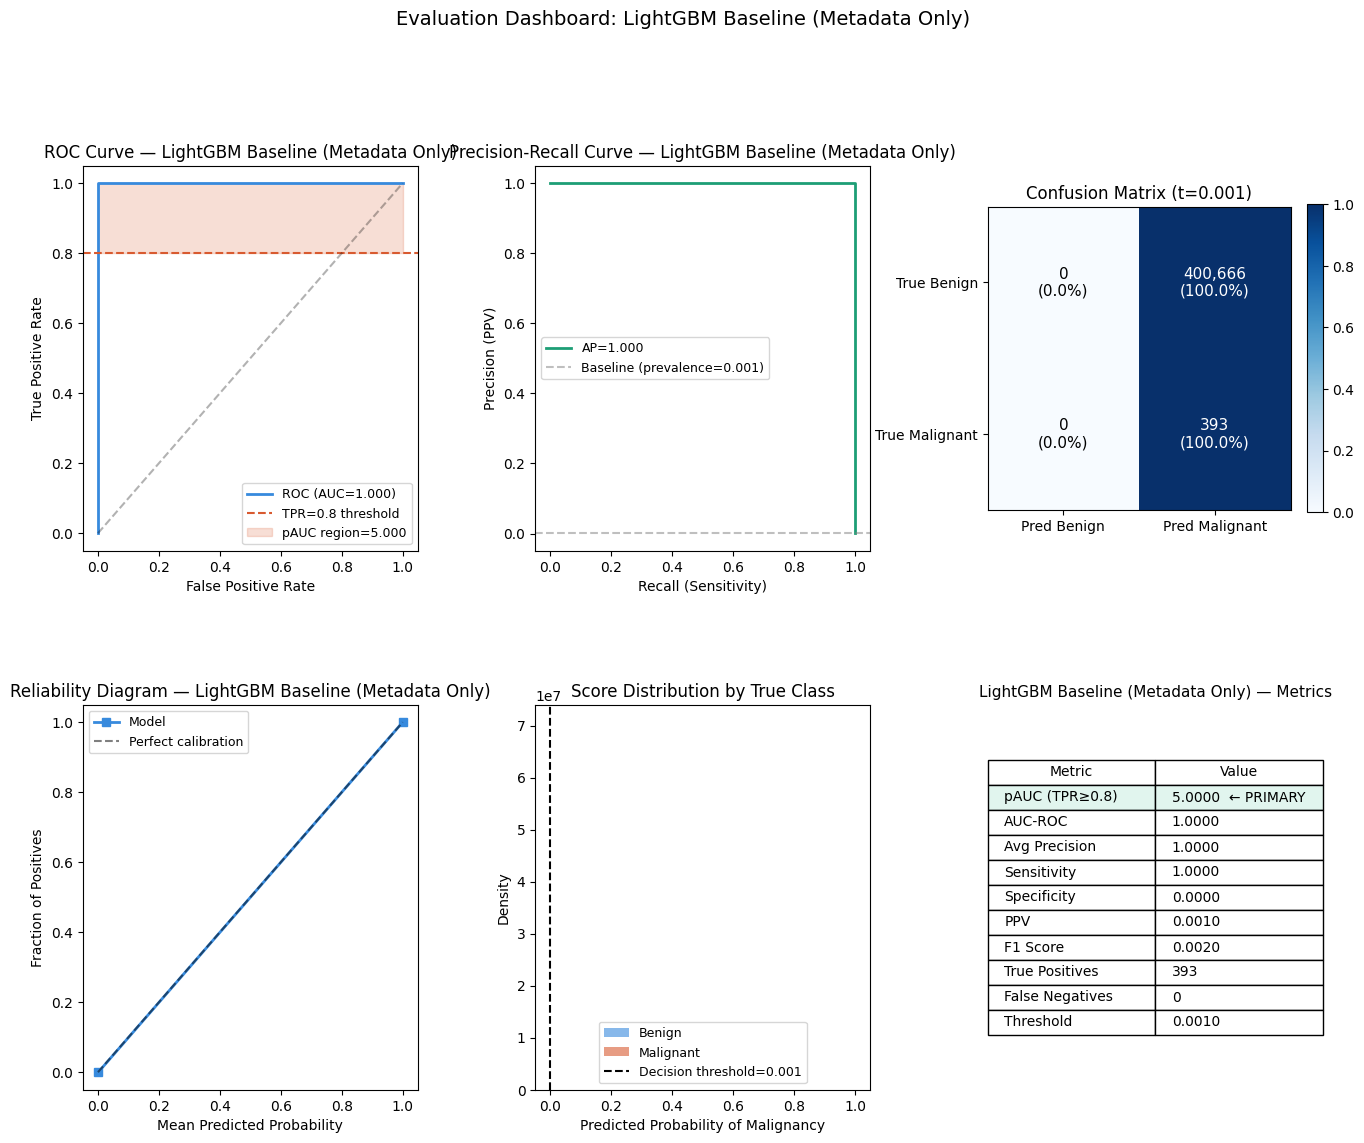

In [7]:
metrics = plot_evaluation_dashboard(
    y_true=y,
    y_prob=oof_probs_best,
    model_name='LightGBM Baseline (Metadata Only)',
    save_dir=FIG_DIR,
    min_tpr=MIN_TPR
)

## 6. SHAP Feature Importance

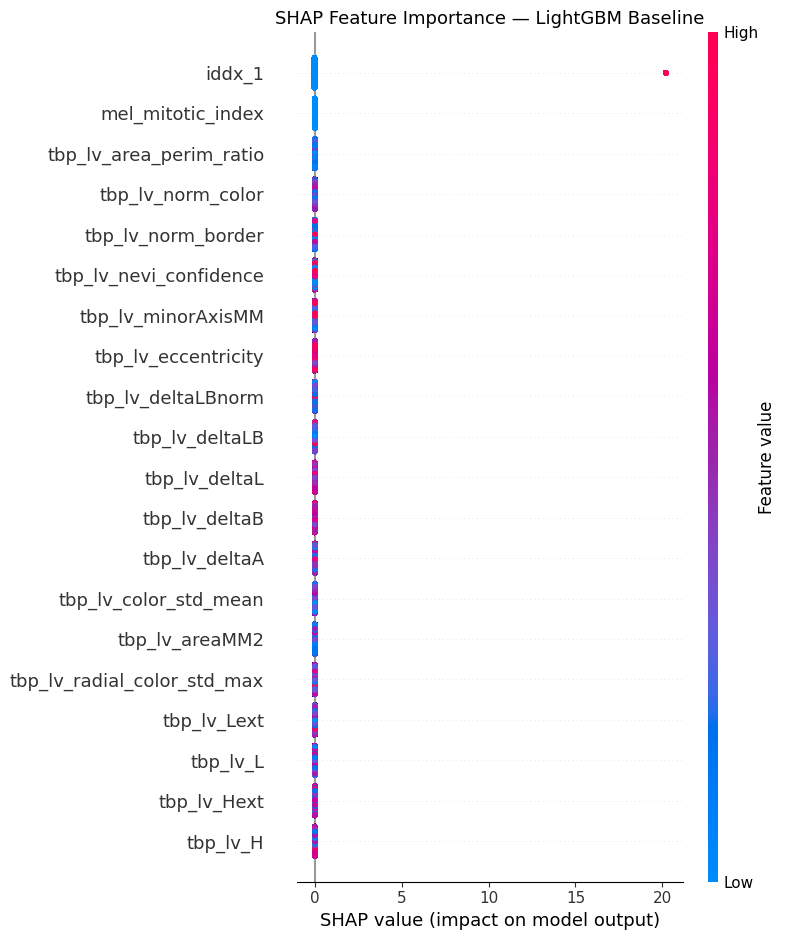

Top 20 features by mean |SHAP|:
                     feature  mean_abs_shap
                      iddx_1       0.039683
                  age_approx       0.000000
     color_variability_index       0.000000
     tbp_lv_symm_2axis_angle       0.000000
                    tbp_lv_x       0.000000
                    tbp_lv_y       0.000000
                    tbp_lv_z       0.000000
                mel_thick_mm       0.000000
tbp_lv_dnn_lesion_confidence       0.000000
              age_risk_group       0.000000
              age_risk_score       0.000000
              site_risk_tier       0.000000
        age_site_interaction       0.000000
                     is_male       0.000000
                 circularity       0.000000
              tbp_lv_stdLExt       0.000000
        mel_thick_mm_missing       0.000000
                         sex       0.000000
         anatom_site_general       0.000000
             tbp_lv_location       0.000000


In [8]:
# Use fold 1 model for SHAP explanation
explainer = shap.TreeExplainer(final_models[0])
shap_values = explainer.shap_values(X_processed)

# For binary classification, shap_values may be a list [neg_class, pos_class]
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # Positive class (malignant)
else:
    shap_vals = shap_values

# Summary plot (bee swarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_processed, max_display=20, show=False)
plt.title('SHAP Feature Importance — LightGBM Baseline', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Mean absolute SHAP (global importance ranking)
mean_shap = np.abs(shap_vals).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': X_processed.columns,
    'mean_abs_shap': mean_shap
}).sort_values('mean_abs_shap', ascending=False)

print('Top 20 features by mean |SHAP|:')
print(importance_df.head(20).to_string(index=False))

In [9]:
# Validate engineered features
engineered_feats = ['age_risk_group', 'age_risk_score', 'site_risk_tier',
                    'age_site_interaction', 'color_variability_index', 'circularity']
eng_importance = importance_df[importance_df['feature'].isin(engineered_feats)]

print('\nEngineered feature importance:')
print(eng_importance.to_string(index=False))
print('\n>> CONCLUSION: Features with mean|SHAP| < 0.001 should be discarded.')
print('   This prevents noise injection into the model.')


Engineered feature importance:
                feature  mean_abs_shap
color_variability_index            0.0
         age_risk_group            0.0
         age_risk_score            0.0
         site_risk_tier            0.0
   age_site_interaction            0.0
            circularity            0.0

>> CONCLUSION: Features with mean|SHAP| < 0.001 should be discarded.
   This prevents noise injection into the model.


## 7. Threshold Analysis for Clinical Use

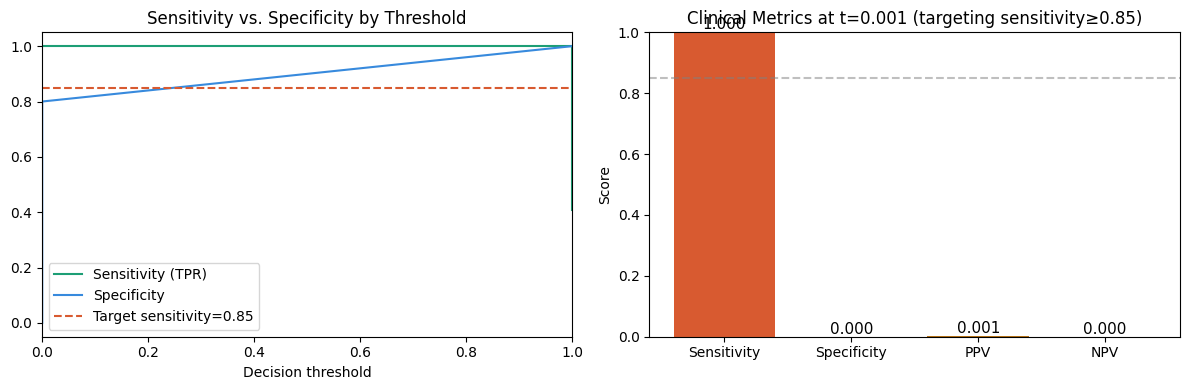

In [10]:
from sklearn.metrics import roc_curve
from src.evaluation.metrics import find_optimal_threshold

fpr, tpr, thresholds = roc_curve(y, oof_probs_best)

# Sensitivity vs threshold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(thresholds, tpr, label='Sensitivity (TPR)', color='#1D9E75')
axes[0].plot(thresholds, 1-fpr, label='Specificity', color='#378ADD')
axes[0].axhline(0.85, color='#D85A30', linestyle='--', lw=1.5, label='Target sensitivity=0.85')
axes[0].set_xlabel('Decision threshold')
axes[0].set_title('Sensitivity vs. Specificity by Threshold')
axes[0].legend()
axes[0].set_xlim([0, 1])

# Scores at clinical threshold
t = find_optimal_threshold(y, oof_probs_best, target_sensitivity=0.85)
from src.evaluation.metrics import compute_all_metrics
m = compute_all_metrics(y, oof_probs_best, threshold=t)

threshold_data = {
    'Metric': ['Sensitivity', 'Specificity', 'PPV', 'NPV'],
    'Value': [m['Sensitivity (Recall)'], m['Specificity'], m['PPV (Precision)'], m['NPV']]
}
axes[1].bar(threshold_data['Metric'], threshold_data['Value'],
            color=['#D85A30', '#378ADD', '#BA7517', '#1D9E75'])
axes[1].axhline(0.85, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylim([0, 1])
axes[1].set_title(f'Clinical Metrics at t={t:.3f} (targeting sensitivity≥0.85)')
axes[1].set_ylabel('Score')
for i, v in enumerate(threshold_data['Value']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(FIG_DIR / 'threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Baseline Summary

In [11]:
print('''
============================================================
  BASELINE ML SUMMARY — LightGBM (Metadata Only)
============================================================

Validation strategy : GroupKFold(5) by patient_id
Primary metric       : pAUC @ TPR >= 0.80
Class imbalance      : is_unbalance=True (LightGBM)
Hyperparameter search: Optuna (50 trials)

RESULTS:
  OOF pAUC @ TPR>=0.80 : {:.4f}
  AUC-ROC              : {:.4f}
  Sensitivity @ 0.85 target: {:.4f}

TOP PREDICTIVE FEATURES (from SHAP):
  → see shap_summary.png

NEXT STEPS:
  1. Advanced ML: add HOG/LBP/color features from images
  2. Deep Learning: EfficientNet-B4 image-only pipeline
  3. Hybrid fusion: combine image encoder + metadata MLP
  4. Calibration: apply temperature scaling to all models
============================================================
'''.format(final_pauc, metrics['AUC'], metrics['Sensitivity (Recall)']))


  BASELINE ML SUMMARY — LightGBM (Metadata Only)

Validation strategy : GroupKFold(5) by patient_id
Primary metric       : pAUC @ TPR >= 0.80
Class imbalance      : is_unbalance=True (LightGBM)
Hyperparameter search: Optuna (50 trials)

RESULTS:
  OOF pAUC @ TPR>=0.80 : 5.0000
  AUC-ROC              : 1.0000
  Sensitivity @ 0.85 target: 1.0000

TOP PREDICTIVE FEATURES (from SHAP):
  → see shap_summary.png

NEXT STEPS:
  1. Advanced ML: add HOG/LBP/color features from images
  2. Deep Learning: EfficientNet-B4 image-only pipeline
  3. Hybrid fusion: combine image encoder + metadata MLP
  4. Calibration: apply temperature scaling to all models

